In [2]:
import math
import matplotlib.pyplot as plt
from matplotlib.animation import FFMpegFileWriter
from matplotlib.gridspec import GridSpec
import numpy as np
import scipy as sp
import time

In [3]:
def timer_dec(base_func):
    def extended_func(*args, **kwargs):
        start = time.time()
        result = base_func(*args, **kwargs)
        end = time.time()
        enlapsed_s = end - start
        print(f"enlapsed_us of {base_func.__name__}: {enlapsed_s:.2f}s ")
        return result

    return extended_func

In [4]:
class Grid:
    def __init__(self,Nx,L):
        self.Nx = Nx 
        self.L = L
        self.dx  = L / Nx 

        self.x = np.linspace(-L/2,L/2,Nx,endpoint=False)
        self.k = 2.0 * np.pi * np.fft.fftfreq(Nx,d = self.dx)


In [5]:
class Potential:
    @staticmethod
    def finite_barrier(x,x0,x1,height):
        V = np.zeros_like(x)
        mask = (x >= x0) & (x <= x1)
        V[mask] = height
        return V

In [6]:
class WaveFunction:
    def __init__(self,grid):
        self.grid = grid
        
    def gaussian(self,x0,k0,sigma):
       psi =  np.exp(1j * k0 * self.grid.x)* np.exp( - (self.grid.x - x0)**2 / (2 * sigma**2) )
       return self.normalize(psi)

    def normalize(self,psi):
        dx = self.grid.dx
        return psi / np.sqrt(np.sum(np.abs(psi)**2) * dx)
        


In [7]:
class TDSESolver:
    def __init__(self,grid,dt,V,m=1.0,hbar=1.0):
        self.grid = grid
        self.dt = dt
        self.V = V
        self.m = m
        self.hbar = hbar

        self.T_k = np.exp(-1j * (hbar * grid.k**2 / (2 *m ))* dt)
        self.V_half = np.exp(-1j * V * dt / (2 * hbar))

    def step(self,psi):
        # 1st half step
        psi = self.V_half * psi

        # Fourier Transform from x t p

        psi_k = np.fft.fft(psi)

        # Apply Kinetic engery operator
        psi_k *= self.T_k

        # Inverse Fourier Transfrom from p to x
        psi = np.fft.ifft(psi_k) 

        # 2nd Half step
        psi  =  self.V_half * psi

        return psi
    @timer_dec
    def run(self,psi0,Nt):

        psi = psi0.copy()
        res = []

        for _ in range(Nt):
            psi = self.step(psi)
           # psi /= np.sqrt(np.sum(np.abs(psi)**2) * self.grid.dx)
            res.append(psi)

        return np.array(res)
    
        

In [8]:
class Observerables:
    def __init__(self,grid,potential):
        self.x = grid.x
        self.dx = grid.dx
        self.V = potential

    def transmission_reflection(self,psi,barrier_left,barrier_right):
        prob_density = np.abs(psi)**2

        left = self.x < barrier_left
        right = self.x > barrier_right

        R = np.sum(prob_density[left]) * self.dx
        T = np.sum(prob_density[right]) * self.dx
        return T, R

    def potential_energy(self,psi):
        return np.sum(np.abs(psi)**2 * self.V) * self.dx
    
    
    def kinetic_energy(self, psi, grid, hbar=1.0, m=1.0):
        psi_k = np.fft.fft(psi) 
      

        energy_k = (hbar**2 * grid.k**2) / (2*m)

        return np.sum(np.abs(psi_k)**2 * energy_k) * grid.dx / grid.Nx   
    @timer_dec
    def track_all(self,res,grid,barrier_left,barrier_right):
        T_list, R_list = [] , []
        KE_list, PE_list  = [] , []

        for psi in res:

            T,R = self.transmission_reflection(psi,barrier_left,barrier_right)
            KE = self.kinetic_energy(psi,grid)
            PE = self.potential_energy(psi)

            T_list.append(T)
            R_list.append(R)
            PE_list.append(PE)
            KE_list.append(KE)
        return T_list,R_list,KE_list,PE_list

In [9]:
Nx = 1000
L = 200.0

# Potential Constants
barrier_height = 2
barrier_left = -2
barrier_right = 2

# wavefunction Constants
sigma = 3
k0 = 2
x0 = -30
# Time domain constants
Nt = 1500
Time_Period =  2.5 * (abs(x0) + 5 * sigma) / k0
dt = Time_Period / Nt 
t = np.linspace(0,Time_Period,Nt)
grid = Grid(Nx,L)
wavefunc = WaveFunction(grid).gaussian(x0,k0,sigma)
potential = Potential.finite_barrier(grid.x,barrier_left,barrier_right,barrier_height)

obser = Observerables(grid,potential)


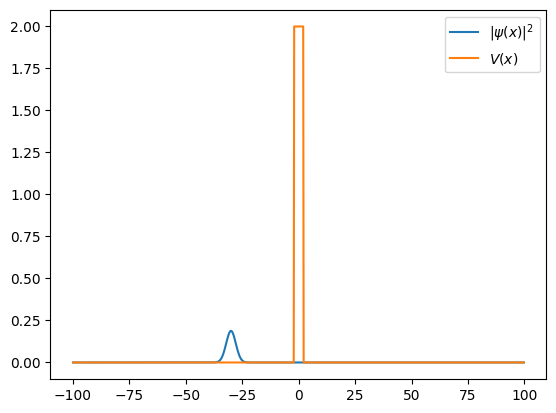

In [10]:
plt.plot(grid.x,np.abs(wavefunc)**2,label = r"$|\psi(x)|^2$")
plt.plot(grid.x,potential,label = r"$V(x)$")
plt.legend()

In [11]:
solver = TDSESolver(grid,dt,potential)
solution = solver.run(wavefunc,Nt)

enlapsed_us of run: 0.13s 


enlapsed_us of track_all: 0.12s 
Initial H: 2.0277777777777786
Final H: 2.0277777764461704
Difference Final - Initial: -1.3316081570735605e-09


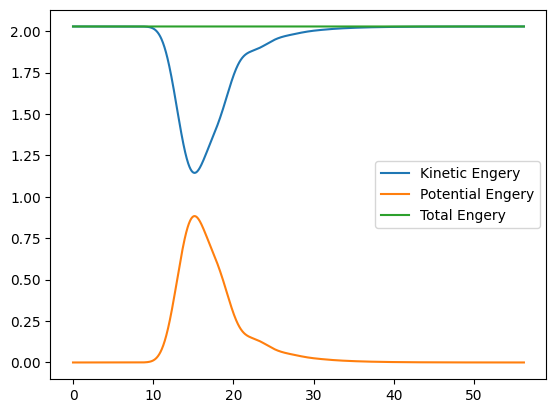

In [12]:
T, R, KE, PE =obser.track_all(solution,grid,barrier_left,barrier_right)
H = np.add(KE,PE)
H_len = len(H)

plt.plot(t,KE,label="Kinetic Engery")
plt.plot(t,PE,label="Potential Engery")
plt.plot(t,H,label = "Total Engery")
plt.legend()

print(f"Initial H: {H[0]}")
print(f"Final H: {H[H_len - 1]}")
print(f"Difference Final - Initial: {H[H_len - 1] - H[0]}")


0.9999716104559935
1.0
-2.8389544006524048e-05


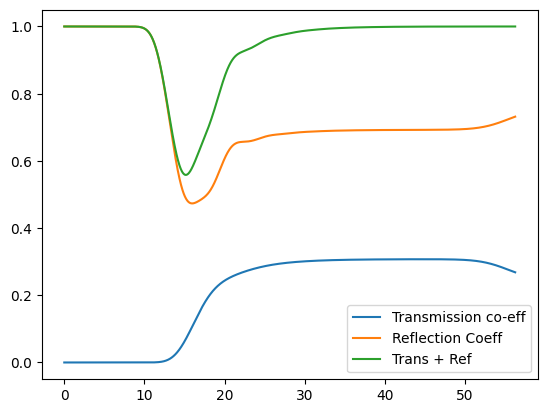

In [13]:
plt.plot(t,T,label = "Transmission co-eff")
plt.plot(t,R,label = "Reflection Coeff")
P = np.add(T,R)
plt.plot(t,P, label =
          "Trans + Ref")
plt.legend()
print(P[len(P)-1])
print(P[0])
print(P[len(P) -1 ] - P[0] )

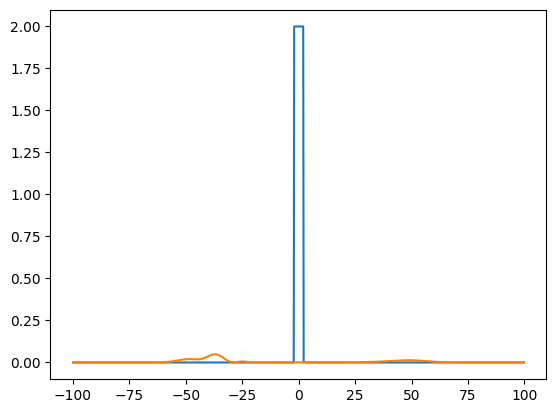

In [14]:
plt.plot(grid.x,potential)
plt.plot(grid.x, np.abs(solution[1000])**2)

In [15]:
from matplotlib.gridspec import GridSpec
from matplotlib.animation import FFMpegFileWriter
import numpy as np
import matplotlib.pyplot as plt

class Plo_t:
    def __init__(self, grid, solution, potential, time, T, R, KE, PE):
        self.grid = grid
        self.solution = solution
        self.potential = potential
        self.time = time
        self.T = T
        self.R = R
        self.KE = KE
        self.PE = PE
        self.H = np.add(KE,PE)

    @timer_dec
    def animate_density_video(self, outname, out_codec, fps=30):

        # --- Scaling (DO NOT overwrite original potential) ---
        potential_max = np.max(self.potential)
        potential_min = np.min(self.potential)
        pot_norm = self.potential / potential_max

        psi_real_max = np.max(self.solution.real)
        psi_imag_max = np.max(self.solution.imag)
        psi_den_max  = np.max(np.abs(self.solution)**2)

        psi_real_min = np.min(self.solution.real)
        psi_imag_min = np.min(self.solution.imag)
        psi_den_min  = np.min(np.abs(self.solution)**2)

        y_max = max(psi_real_max, psi_imag_max, psi_den_max, potential_max)
        y_min = min(psi_real_min, psi_imag_min, psi_den_min, potential_min)

        # --- Layout (LEFT big, RIGHT split) ---
        fig = plt.figure(figsize=(10, 6), dpi=100)
        gs = GridSpec(2, 2, width_ratios=[1, 1], height_ratios=[1, 1])

        ax0 = fig.add_subplot(gs[:, 0])  # Wavefunction
        ax1 = fig.add_subplot(gs[0, 1])  # T/R
        ax2 = fig.add_subplot(gs[1, 1])  # Energy

        plt.subplots_adjust(wspace=0.3, hspace=0.4)

        # --- Wavefunction ---
        ax0.set_xlim(self.grid.x.min(), self.grid.x.max())
        ax0.set_ylim(y_min, y_max)
        ax0.set_xlabel("x")

        (real,) = ax0.plot([], [], color="#d62728", label=r"$\psi(x)$")
        (imag,) = ax0.plot([], [], color="#1f77b4", label=r"$\psi^*(x)$")
        (den,)  = ax0.plot([], [], color="#ff7f0e", label=r"$|\psi(x)|^2$")
        (pot,)  = ax0.plot([], [], color="#2ca02c", label=r"$V(x)$")

        ax0.legend(loc="upper right", fontsize=8)
        ax0.grid(alpha=0.3)

        # --- Transmission / Reflection ---
        ax1.set_xlim(self.time.min(), self.time.max())
        ax1.set_ylim(0, 1.5)
        ax1.set_xlabel("t")

        (Transmission,) = ax1.plot([], [], color="#2ca02c", label="Transmission")
        (Reflection,)   = ax1.plot([], [], color="#ff7f0e", label="Reflection")
        (TR,)           = ax1.plot([], [], color="#1f77b4", label="T+R")

        ax1.legend(loc="upper right", fontsize=8)
        ax1.grid(alpha=0.3)

        # --- Energy ---
        ax2.set_xlim(self.time.min(), self.time.max())
        ax2.set_xlabel("t")

        e_max = max(np.max(self.PE), np.max(self.KE), np.max(self.H))
        e_min = min(np.min(self.PE), np.min(self.KE), np.min(self.H))
        ax2.set_ylim(e_min - 0.5, e_max + 0.5)

        (KE_line,) = ax2.plot([], [], color="#CC79A7", label="Kinetic Energy")
        (PE_line,) = ax2.plot([], [], color="#D55E00", label="Potential Energy")
        (H_line,)  = ax2.plot([], [], color="#0072B2", label="Total Energy")

        ax2.legend(loc="upper right", fontsize=8)
        ax2.grid(alpha=0.3)

        # --- Writer ---
        writer = FFMpegFileWriter(fps=fps, codec=out_codec)

        x = self.grid.x
        T_vals, R_vals, TR_vals = [], [], []
        time_vals = []
        KE_vals, PE_vals, H_vals = [], [], []

        with writer.saving(fig, outname, dpi=100):
            for i in range(0, len(self.solution), 10):

                # Wavefunction
                real.set_data(x, self.solution.real[i])
                imag.set_data(x, self.solution.imag[i])
                den.set_data(x, np.abs(self.solution[i])**2)
                pot.set_data(x, pot_norm)

                # Time series accumulation
                time_vals.append(self.time[i])
                T_vals.append(self.T[i])
                R_vals.append(self.R[i])
                TR_vals.append(self.T[i] + self.R[i])

                KE_vals.append(self.KE[i])
                PE_vals.append(self.PE[i])
                H_vals.append(self.H[i])

                # Update plots
                Transmission.set_data(time_vals, T_vals)
                Reflection.set_data(time_vals, R_vals)
                TR.set_data(time_vals, TR_vals)

                PE_line.set_data(time_vals, PE_vals)
                KE_line.set_data(time_vals, KE_vals)
                H_line.set_data(time_vals, H_vals)

                # Titles
                ax0.set_title(f"Time step: {i:04d}", pad=10)
                ax1.set_title("Transmission / Reflection", pad=10)
                ax2.set_title("Energy", pad=10)

                writer.grab_frame()

        plt.close(fig)

In [18]:
file_name = "results/finite-barrier/out.gif"
plotting = Plo_t(grid,solution,potential,t,T,R,KE,PE)
plotting.animate_density_video(file_name,"gif")

enlapsed_us of animate_density_video: 25.91s 
